In [2]:
%pip install mlxtend
%pip install yellowbrick

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 23.1.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from yellowbrick.cluster import KElbowVisualizer
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report,accuracy_score
import lightgbm as lgb
from sklearn.metrics import *






In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv', sep=';')
pd.set_option('display.max_columns', None)
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.shape

(1599, 12)

In [6]:
duplicated_rows = df.duplicated().sum()
duplicated_rows

np.int64(240)

In [7]:
df.drop_duplicates(inplace=True)

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(1359, 12)

In [10]:
missing = df.isna().mean()*100
missing


fixed acidity           0.0
volatile acidity        0.0
citric acid             0.0
residual sugar          0.0
chlorides               0.0
free sulfur dioxide     0.0
total sulfur dioxide    0.0
density                 0.0
pH                      0.0
sulphates               0.0
alcohol                 0.0
quality                 0.0
dtype: float64

In [11]:
df.skew()

fixed acidity           0.941041
volatile acidity        0.729279
citric acid             0.312726
residual sugar          4.548153
chlorides               5.502487
free sulfur dioxide     1.226579
total sulfur dioxide    1.540368
density                 0.044778
pH                      0.232032
sulphates               2.406505
alcohol                 0.859841
quality                 0.192407
dtype: float64

In [12]:
def quality_label (q):
    if q <= 4:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2
    
df['label'] = df['quality'].apply(quality_label)

In [13]:
X = df.drop(['label','quality'],axis=1)
y = df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
#outliers

X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1087.0,8.293376,1.726004,4.60000,7.1000,7.9000,9.1000,15.90000
volatile acidity,1087.0,0.527732,0.178433,0.16000,0.3900,0.5200,0.6400,1.58000
citric acid,1087.0,0.273303,0.195378,0.00000,0.1000,0.2600,0.4200,1.00000
residual sugar,1087.0,2.525483,1.365678,0.90000,1.9000,2.2000,2.6000,15.50000
chlorides,1087.0,0.089592,0.052481,0.01200,0.0700,0.0800,0.0910,0.61100
free sulfur dioxide,1087.0,15.740570,10.335814,1.00000,7.0000,14.0000,21.0000,72.00000
total sulfur dioxide,1087.0,46.849126,33.300148,6.00000,22.0000,38.0000,63.0000,289.00000
density,1087.0,0.996698,0.001863,0.99007,0.9956,0.9967,0.9978,1.00369
pH,1087.0,3.309540,0.152251,2.74000,3.2100,3.3100,3.4000,3.90000
sulphates,1087.0,0.659669,0.173844,0.33000,0.5500,0.6200,0.7300,2.00000


In [16]:
# Lista de columnas que quiero analizar
columnas = ['fixed acidity', 'volatile acidity', 'residual sugar','chlorides','free sulfur dioxide','total sulfur dioxide','sulphates']

# Para guardar los resultados
resultados = []

# Analizar cada columna una por una
for columna in columnas:
    
    # Obtener los datos de la columna
    datos = df[columna]
    
    # Calcular Q1 (25%), Q3 (75%) y IQR
    Q1 = datos.quantile(0.25)  # 25% de los datos
    Q3 = datos.quantile(0.75)  # 75% de los datos
    IQR = Q3 - Q1              # Diferencia entre Q3 y Q1
    
    # Calcular límites
    limite_bajo = Q1 - 1.5 * IQR
    limite_alto = Q3 + 1.5 * IQR
    
    # Contar outliers
    outliers_bajos = (datos < limite_bajo).sum()
    outliers_altos = (datos > limite_alto).sum()
    total_outliers = outliers_bajos + outliers_altos
    
    # Calcular porcentaje
    porcentaje = (total_outliers / len(datos)) * 100
    
    # Guardar en la lista
    resultados.append({
        'Columna': columna,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Limite_Bajo': limite_bajo,
        'Limite_Alto': limite_alto,
        'Total_Outliers': total_outliers,
        'Porcentaje': round(porcentaje, 2)
    })

# Convertir a DataFrame para verlo bonito
df_outliers = pd.DataFrame(resultados)

# Mostrar resultados
print("="*80)
print("ANÁLISIS DE OUTLIERS")
print("="*80)
print(df_outliers)
print("="*80)

# Explicar qué significa
print("\n💡 INTERPRETACIÓN:")
for i in range(len(df_outliers)):
    col = df_outliers.loc[i, 'Columna']
    limite_bajo = df_outliers.loc[i, 'Limite_Bajo']
    limite_alto = df_outliers.loc[i, 'Limite_Alto']
    total = df_outliers.loc[i, 'Total_Outliers']
    pct = df_outliers.loc[i, 'Porcentaje']
    
    print(f"\n{col}:")
    print(f"  - Valores normales: entre {limite_bajo:.1f} y {limite_alto:.1f}")
    print(f"  - Outliers encontrados: {total} ({pct}%)")
    
    if pct < 5:
        print(f"  ✅ Pocos outliers, está bien")
    elif pct < 10:
        print(f"  ⚠️ Algunos outliers")
    else:
        print(f"  ❌ Muchos outliers")

ANÁLISIS DE OUTLIERS
                Columna     Q1      Q3     IQR  Limite_Bajo  Limite_Alto  \
0         fixed acidity   7.10   9.200   2.100       3.9500      12.3500   
1      volatile acidity   0.39   0.640   0.250       0.0150       1.0150   
2        residual sugar   1.90   2.600   0.700       0.8500       3.6500   
3             chlorides   0.07   0.091   0.021       0.0385       0.1225   
4   free sulfur dioxide   7.00  21.000  14.000     -14.0000      42.0000   
5  total sulfur dioxide  22.00  63.000  41.000     -39.5000     124.5000   
6             sulphates   0.55   0.730   0.180       0.2800       1.0000   

   Total_Outliers  Porcentaje  
0              41        3.02  
1              19        1.40  
2             126        9.27  
3              87        6.40  
4              26        1.91  
5              45        3.31  
6              55        4.05  

💡 INTERPRETACIÓN:

fixed acidity:
  - Valores normales: entre 4.0 y 12.3
  - Outliers encontrados: 41 (3.02%)
  ✅

In [17]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [24]:
knn= KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_sc,y_train)
y_pred = knn.predict(X_test_sc)

In [25]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.8198529411764706

In [20]:
report = classification_report(y_test,y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        15
           1       0.86      0.93      0.89       223
           2       0.55      0.47      0.51        34

    accuracy                           0.82       272
   macro avg       0.47      0.47      0.47       272
weighted avg       0.78      0.82      0.80       272



findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

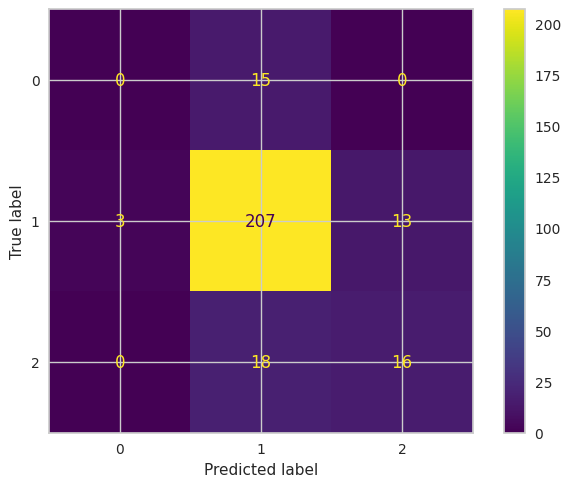

In [32]:
cm = confusion_matrix(y_test, y_pred)
cm

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

El modelo predice muy bien la clase 1. Pero no distingue bien las carácterísticas de la clase 0 y confunde la clase 2. 

Optimizar encontrando el mejor valor de K

In [26]:
Krange = range(1,21)
accu = []

for k in Krange:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_sc,y_train)
    bestk_pred = model.predict(X_test_sc)
    accu.append(accuracy_score(y_test,bestk_pred))



Graficar accuracy vs K

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Liberation Sans, Bitstream Vera Sans, sans-serif
findfont: Generic family 'sans-serif' not found because none of the fo

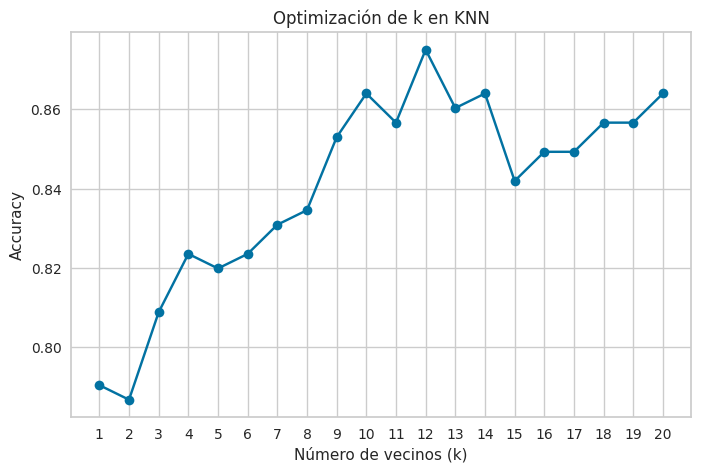

In [28]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 21), accu, marker="o")
plt.title("Optimización de k en KNN")
plt.xlabel("Número de vecinos (k)")
plt.ylabel("Accuracy")
plt.xticks(range(1, 21))
plt.grid(True)
plt.show()

Mejor valor de K

In [37]:
best_k = accu.index(max(accu)) + 1
print(f"El mejor valor de k es {best_k} con accuracy = {max(accu)}")


El mejor valor de k es 12 con accuracy = 0.875


In [38]:
final_model = KNeighborsClassifier(n_neighbors= best_k)
final_model.fit(X_train_sc,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",12
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Función para predecir calidad

In [ ]:
def q_prediction(valor):
  
    # Escalar los valores con el mismo scaler
    valores_scaled = scaler.transform([valor])
    # Predecir con el modelo entrenado
    prediccion = knn.predict(valores_scaled)
    return prediccion[0]

wine_test = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
print("Predicción de calidad:", q_prediction(wine_test))


Predicción de calidad: 1


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
